# Helsinki & Espoo City Bikes: Network Analysis Notebook

This notebook implements the network-analysis workflow inspired by the Medium article (centrality and community detection), and extends it with additional exploratory directions useful for the research plan:

1. Directed OD graph construction from trip flows
2. Centrality analysis (degree, betweenness, closeness, PageRank, eigenvector)
3. Community detection (Louvain + optional Fluid communities)
4. Temporal stability of community structure
5. Additional exploration: resilience under hub failures, cross-city edge mixing

The graph views used in forecasting (SD, DE, DC, ATD) are static in the plan baseline; this notebook focuses on **analysis/interpretation**, not dynamic graph generation for training.

In [45]:
from __future__ import annotations

from pathlib import Path
import math

import numpy as np
import pandas as pd
import polars as pl
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

_candidates = [Path.cwd().resolve(), Path('.').resolve()]
PROJECT_ROOT = next((
    ancestor
    for base in _candidates
    for ancestor in (base, *base.parents)
    if (ancestor / 'data' / 'prepared' / 'splits' / 'train' / 'train.csv').exists()
    or (ancestor / 'data' / 'prepared' / 'merged' / 'trips_merged.csv').exists()
), next((
    ancestor
    for base in _candidates
    for ancestor in (base, *base.parents)
    if (ancestor / 'data' / 'train' / 'train.csv').exists()
    or (ancestor / 'data' / 'merged' / 'trips_merged.csv').exists()
), next((
    ancestor
    for base in _candidates
    for ancestor in (base, *base.parents)
    if (ancestor / 'data').exists()
), Path('.').resolve())))

DATA_DIR = PROJECT_ROOT / 'data'
PRIMARY_DIR = DATA_DIR / 'primary'
PREPARED_DIR = DATA_DIR / 'prepared'
ARTIFACTS_DIR = DATA_DIR / 'artifacts'

TRAIN_PATH = PREPARED_DIR / 'splits' / 'train' / 'train.csv'
VAL_PATH = PREPARED_DIR / 'splits' / 'validation' / 'validation.csv'
TEST_PATH = PREPARED_DIR / 'splits' / 'test' / 'test.csv'
MERGED_PATH = PREPARED_DIR / 'merged' / 'trips_merged.csv'
NETWORK_OUT_DIR = ARTIFACTS_DIR / 'network' / 'notebook'
NETWORK_OUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_SCHEMA_OVERRIDES = {
    'departure_id': pl.String,
    'return_id': pl.String,
    'departure_name': pl.String,
    'return_name': pl.String,
}

RANDOM_STATE = 42
APPROX_BETWEENNESS = True
BETWEENNESS_SAMPLE_K = 200
MIN_FLOW = 1

In [46]:
def load_trips() -> pl.DataFrame:
    candidates = [TRAIN_PATH, MERGED_PATH]
    for path in candidates:
        if path.exists():
            df = pl.read_csv(path, try_parse_dates=True, schema_overrides=CSV_SCHEMA_OVERRIDES)
            print(f'Loaded: {path} ({df.height:,} rows, {df.width} cols)')
            return df
    raise FileNotFoundError('No train.csv or trips_merged.csv found. Run prepare_data.py first.')


def preprocess_trips(df: pl.DataFrame) -> pl.DataFrame:
    required = ['departure_name', 'return_name', 'departure']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f'Missing required columns: {missing}')

    out = (
        df
        .with_columns([
            pl.col('departure_name').cast(pl.String, strict=False).str.strip_chars().alias('departure_name'),
            pl.col('return_name').cast(pl.String, strict=False).str.strip_chars().alias('return_name'),
            pl.col('departure').cast(pl.String, strict=False).str.strptime(pl.Datetime, strict=False).alias('departure_ts'),
        ])
        .drop_nulls(['departure_name', 'return_name', 'departure_ts'])
    )

    if 'city' not in out.columns and '_year' in out.columns:
        pass

    return out


trips = preprocess_trips(load_trips())
print(trips.select([
    pl.min('departure_ts').alias('min_departure_ts'),
    pl.max('departure_ts').alias('max_departure_ts'),
]))

Loaded: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\prepared\splits\train\train.csv (14,450,455 rows, 16 cols)
shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ min_departure_ts    ┆ max_departure_ts    │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 2016-05-02 09:31:00 ┆ 2021-09-30 23:58:41 │
└─────────────────────┴─────────────────────┘


## Build Directed OD Graph

In [16]:
def build_od_flow(df: pl.DataFrame, min_flow: int = 1) -> pl.DataFrame:
    flow = (
        df
        .group_by(['departure_name', 'return_name'])
        .len()
        .rename({'len': 'flow'})
        .filter(pl.col('flow') >= min_flow)
    )
    return flow


def build_graph(flow_df: pl.DataFrame) -> nx.DiGraph:
    g = nx.DiGraph()
    for row in flow_df.iter_rows(named=True):
        src = row['departure_name']
        dst = row['return_name']
        if src == dst:
            continue
        weight = float(row['flow'])
        g.add_edge(src, dst, flow=weight, cost=1.0 / max(weight, 1e-9))
    return g


flow_df = build_od_flow(trips, min_flow=MIN_FLOW)
G = build_graph(flow_df)

print(f'Nodes: {G.number_of_nodes():,}')
print(f'Edges: {G.number_of_edges():,}')
print(f'Total OD flow represented: {int(flow_df["flow"].sum()):,}')

Nodes: 449
Edges: 80,442
Total OD flow represented: 14,450,455


In [17]:
density = nx.density(G)
wcc = list(nx.weakly_connected_components(G))
largest_wcc = max((len(c) for c in wcc), default=0)

print(f'Density: {density:.6f}')
print(f'Weakly connected components: {len(wcc)}')
print(f'Largest WCC size: {largest_wcc:,}')

Density: 0.399907
Weakly connected components: 1
Largest WCC size: 449


## Centrality Analysis (Medium-style core section)

In [18]:
UG = G.to_undirected()

out_degree = dict(G.out_degree())
in_degree = dict(G.in_degree())
out_strength = dict(G.out_degree(weight='flow'))
in_strength = dict(G.in_degree(weight='flow'))

if APPROX_BETWEENNESS:
    k = min(BETWEENNESS_SAMPLE_K, max(10, UG.number_of_nodes() // 2))
    betweenness = nx.betweenness_centrality(UG, k=k, seed=RANDOM_STATE, weight='cost', normalized=True)
else:
    betweenness = nx.betweenness_centrality(UG, weight='cost', normalized=True)

closeness = nx.closeness_centrality(UG, distance='cost')
pagerank = nx.pagerank(G, weight='flow')

try:
    eigenvector = nx.eigenvector_centrality(UG, weight='flow', max_iter=1000, tol=1e-6)
except nx.PowerIterationFailedConvergence:
    eigenvector = {n: np.nan for n in G.nodes()}

centrality_df = pd.DataFrame({
    'station_name': list(G.nodes()),
    'out_degree': [out_degree.get(n, 0) for n in G.nodes()],
    'in_degree': [in_degree.get(n, 0) for n in G.nodes()],
    'out_strength': [out_strength.get(n, 0.0) for n in G.nodes()],
    'in_strength': [in_strength.get(n, 0.0) for n in G.nodes()],
    'betweenness': [betweenness.get(n, 0.0) for n in G.nodes()],
    'closeness': [closeness.get(n, 0.0) for n in G.nodes()],
    'pagerank': [pagerank.get(n, 0.0) for n in G.nodes()],
    'eigenvector': [eigenvector.get(n, np.nan) for n in G.nodes()],
})

centrality_df = centrality_df.sort_values('pagerank', ascending=False).reset_index(drop=True)
centrality_df.head(15)

,station_name,out_degree,in_degree,out_strength,in_strength,betweenness,closeness,pagerank,eigenvector
0,Itämerentori,299,308,335552.0,337720.0,0.198826,162.822982,0.013620,0.360434
1,Töölönlahdenkatu,297,300,258987.0,260639.0,0.111913,162.444016,0.010532,0.278931
2,Kamppi (M),293,289,213513.0,207773.0,0.008184,160.101338,0.008268,0.214493
3,Ympyrätalo,301,302,190405.0,195083.0,0.021130,163.427134,0.008224,0.158263
4,Suomenlahdentie,157,146,63129.0,65791.0,0.016503,142.430298,0.008219,0.000740
5,Kalasatama (M),276,283,139843.0,145191.0,0.439441,165.489289,0.008037,0.068965
6,Rautatientori / länsi,286,287,185733.0,189674.0,0.127787,163.577527,0.007817,0.170866
7,Rautatientori / itä,301,281,170490.0,173291.0,0.027981,163.216284,0.007239,0.149659
8,Sörnäinen (M),287,299,154907.0,149371.0,0.124324,164.400792,0.006919,0.094349
9,Arabian kauppakeskus,272,287,112608.0,117668.0,0.395130,165.470975,0.006889,0.051406


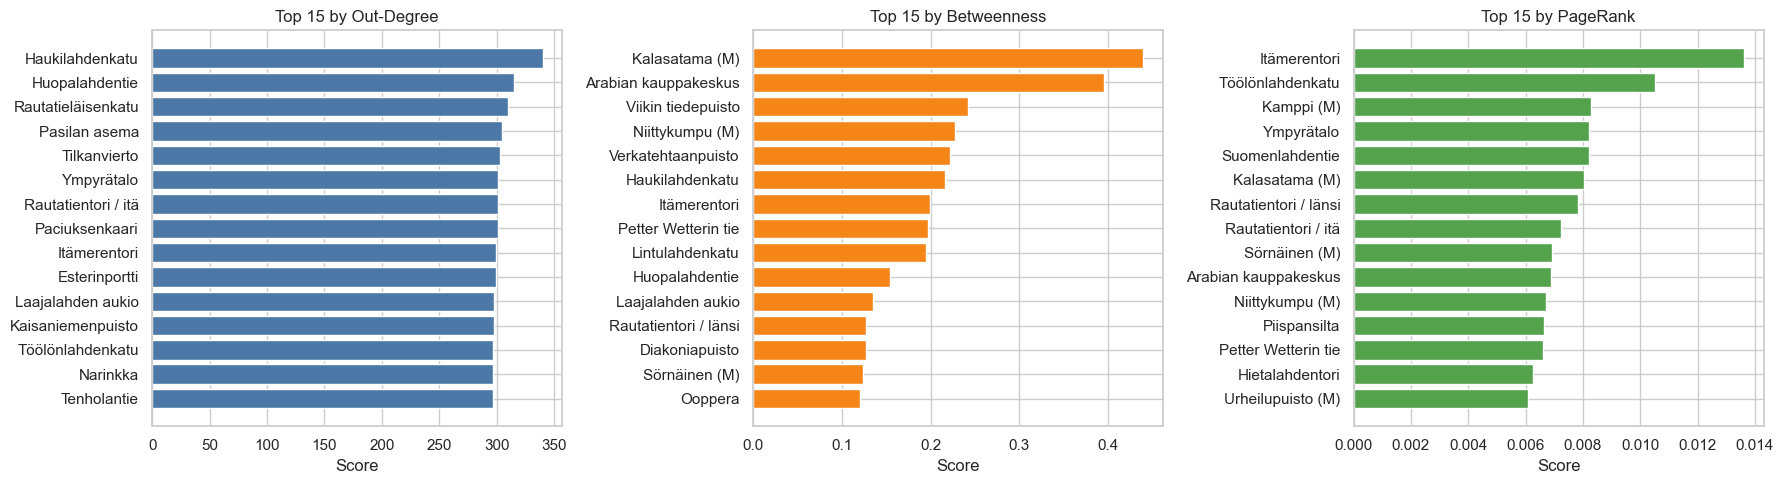

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

top_deg = centrality_df.nlargest(15, 'out_degree').iloc[::-1]
axes[0].barh(top_deg['station_name'], top_deg['out_degree'], color='#4C78A8')
axes[0].set_title('Top 15 by Out-Degree')

top_bw = centrality_df.nlargest(15, 'betweenness').iloc[::-1]
axes[1].barh(top_bw['station_name'], top_bw['betweenness'], color='#F58518')
axes[1].set_title('Top 15 by Betweenness')

top_pr = centrality_df.nlargest(15, 'pagerank').iloc[::-1]
axes[2].barh(top_pr['station_name'], top_pr['pagerank'], color='#54A24B')
axes[2].set_title('Top 15 by PageRank')

for ax in axes:
    ax.set_xlabel('Score')

plt.tight_layout()
plt.show()

## Community Detection (Louvain + Optional Fluid)

In [20]:
def aggregate_to_undirected_weighted(graph: nx.DiGraph) -> nx.Graph:
    ug = nx.Graph()
    for u, v, data in graph.edges(data=True):
        w = float(data.get('flow', 0.0))
        if w <= 0:
            continue
        if ug.has_edge(u, v):
            ug[u][v]['weight'] += w
        else:
            ug.add_edge(u, v, weight=w)
    return ug


UG_flow = aggregate_to_undirected_weighted(G)
louvain_communities = nx.community.louvain_communities(UG_flow, weight='weight', seed=RANDOM_STATE, resolution=1.0)
louvain_modularity = nx.community.modularity(UG_flow, louvain_communities, weight='weight')

louvain_map = {}
for cid, nodes in enumerate(louvain_communities):
    for n in nodes:
        louvain_map[n] = cid

print(f'Louvain communities: {len(louvain_communities)}')
print(f'Louvain modularity: {louvain_modularity:.4f}')

Louvain communities: 6
Louvain modularity: 0.3998


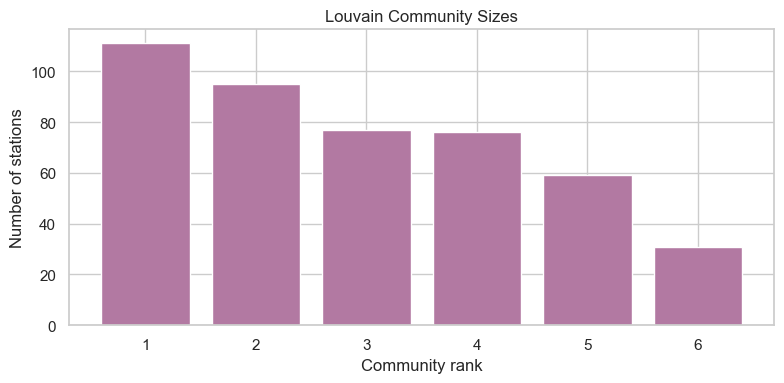

[111, 95, 77, 76, 59, 31]

In [21]:
community_sizes = sorted([len(c) for c in louvain_communities], reverse=True)
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(community_sizes) + 1), community_sizes, color='#B279A2')
plt.title('Louvain Community Sizes')
plt.xlabel('Community rank')
plt.ylabel('Number of stations')
plt.tight_layout()
plt.show()

community_sizes[:10]

In [22]:
# Optional: Fluid communities for comparison with Louvain (if graph is connected).
fluid_results = None
try:
    if nx.is_connected(UG_flow):
        k = min(5, max(2, len(louvain_communities)))
        fluid_communities = list(nx.community.asyn_fluidc(UG_flow, k=k, seed=RANDOM_STATE))

        fluid_map = {}
        for cid, nodes in enumerate(fluid_communities):
            for n in nodes:
                fluid_map[n] = cid

        shared_nodes = sorted(set(louvain_map).intersection(fluid_map))
        if shared_nodes:
            from sklearn.metrics import normalized_mutual_info_score
            l_labels = [louvain_map[n] for n in shared_nodes]
            f_labels = [fluid_map[n] for n in shared_nodes]
            nmi = normalized_mutual_info_score(l_labels, f_labels)
        else:
            nmi = np.nan

        fluid_results = {'k': k, 'nmi_vs_louvain': float(nmi), 'communities': len(fluid_communities)}
    else:
        fluid_results = {'warning': 'Graph is not connected; fluid communities skipped.'}
except Exception as e:
    fluid_results = {'warning': f'Fluid communities unavailable: {e}'}

fluid_results

{'k': 5, 'nmi_vs_louvain': 0.6038848544801337, 'communities': 5}

## Temporal Community Stability (Promising Extension)

In [23]:
from sklearn.metrics import normalized_mutual_info_score

year_df = trips.with_columns(pl.col('departure_ts').dt.strftime('%Y').alias('year'))
years = sorted(year_df.get_column('year').unique().to_list())
year_partitions = {}

for y in years:
    part = year_df.filter(pl.col('year') == y)
    flow_y = build_od_flow(part, min_flow=MIN_FLOW)
    g_y = build_graph(flow_y)
    ug_y = aggregate_to_undirected_weighted(g_y)
    if ug_y.number_of_edges() == 0 or ug_y.number_of_nodes() == 0:
        continue
    comms = nx.community.louvain_communities(ug_y, weight='weight', seed=RANDOM_STATE, resolution=1.0)
    cmap = {}
    for cid, nodes in enumerate(comms):
        for n in nodes:
            cmap[n] = cid
    year_partitions[y] = cmap

stability_rows = []
for y_prev, y_curr in zip(sorted(year_partitions), sorted(year_partitions)[1:]):
    prev_map = year_partitions[y_prev]
    curr_map = year_partitions[y_curr]
    shared = sorted(set(prev_map).intersection(curr_map))
    if not shared:
        continue
    prev_labels = [prev_map[n] for n in shared]
    curr_labels = [curr_map[n] for n in shared]
    nmi = normalized_mutual_info_score(prev_labels, curr_labels)
    stability_rows.append({'previous_year': y_prev, 'current_year': y_curr, 'nmi': nmi, 'shared_nodes': len(shared)})

stability_df = pd.DataFrame(stability_rows)
stability_df

,previous_year,current_year,nmi,shared_nodes
0,2016,2017,0.642773,46
1,2017,2018,0.765706,141
2,2018,2019,0.776468,243
3,2019,2020,0.917060,336
4,2020,2021,0.848280,341


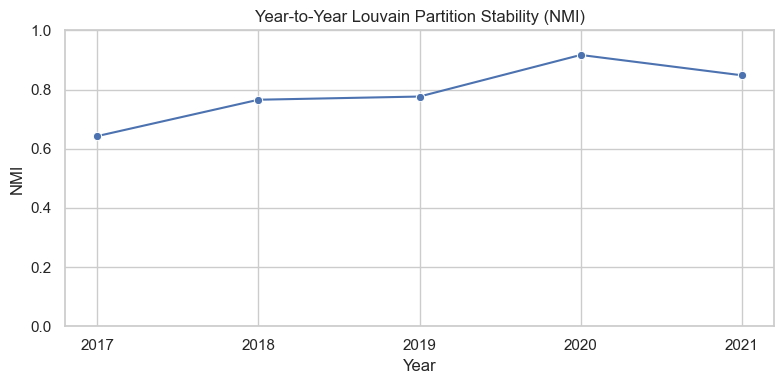

In [24]:
if not stability_df.empty:
    plt.figure(figsize=(8, 4))
    sns.lineplot(data=stability_df, x='current_year', y='nmi', marker='o')
    plt.ylim(0, 1)
    plt.title('Year-to-Year Louvain Partition Stability (NMI)')
    plt.ylabel('NMI')
    plt.xlabel('Year')
    plt.tight_layout()
    plt.show()

## Additional Exploration Directions

In [25]:
# 1) Resilience analysis: remove top-PageRank stations and inspect giant component size.
def giant_component_ratio(graph: nx.DiGraph) -> float:
    if graph.number_of_nodes() == 0:
        return 0.0
    ug = graph.to_undirected()
    if ug.number_of_nodes() == 0:
        return 0.0
    gcc = max(nx.connected_components(ug), key=len)
    return len(gcc) / graph.number_of_nodes()

ranked_nodes = centrality_df['station_name'].tolist()
fractions = [0.0, 0.01, 0.02, 0.05, 0.1]
resilience_rows = []

for frac in fractions:
    g_copy = G.copy()
    k_remove = int(math.floor(frac * G.number_of_nodes()))
    remove_nodes = ranked_nodes[:k_remove]
    g_copy.remove_nodes_from(remove_nodes)
    resilience_rows.append({'removed_fraction': frac, 'giant_component_ratio': giant_component_ratio(g_copy)})

resilience_df = pd.DataFrame(resilience_rows)
resilience_df

,removed_fraction,giant_component_ratio
0,0.00,1.0
1,0.01,1.0
2,0.02,1.0
3,0.05,1.0
4,0.10,1.0


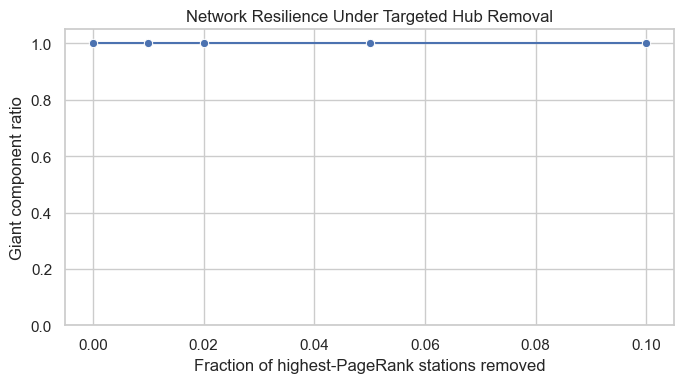

In [26]:
plt.figure(figsize=(7, 4))
sns.lineplot(data=resilience_df, x='removed_fraction', y='giant_component_ratio', marker='o')
plt.title('Network Resilience Under Targeted Hub Removal')
plt.xlabel('Fraction of highest-PageRank stations removed')
plt.ylabel('Giant component ratio')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [27]:
# 2) Cross-city edge mixing (if city metadata available in merged data).
mixing = None
if 'city' in trips.columns:
    city_lookup = (
        trips
        .select(['departure_name', 'city'])
        .drop_nulls(['departure_name', 'city'])
        .unique(subset=['departure_name'], keep='first')
    )
    city_map = dict(zip(city_lookup['departure_name'].to_list(), city_lookup['city'].to_list()))

    rows = []
    for u, v, data in G.edges(data=True):
        cu = city_map.get(u, 'Unknown')
        cv = city_map.get(v, 'Unknown')
        rows.append({'from_city': cu, 'to_city': cv, 'flow': float(data.get('flow', 0.0))})
    mixing = pd.DataFrame(rows).groupby(['from_city', 'to_city'], as_index=False)['flow'].sum()

mixing

## Publication-Ready Figures and Diagnostics

The following section adds publication-oriented visuals and tables that can be used in a paper:

1. Community-to-community flow heatmaps (absolute and normalized)
2. Bridge-vs-hub diagnostics (betweenness vs PageRank)
3. Demand inequality (Lorenz curves + Gini coefficients)
4. Temporal demand signature (hour x weekday)
5. Geographic station map colored by communities

In [29]:
FIG_DIR = NETWORK_OUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 160,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
})


def save_fig(filename: str):
    out = FIG_DIR / filename
    plt.savefig(out, bbox_inches='tight')
    return out


print(f'Figure output directory: {FIG_DIR}')

Figure output directory: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\network\notebook\figures


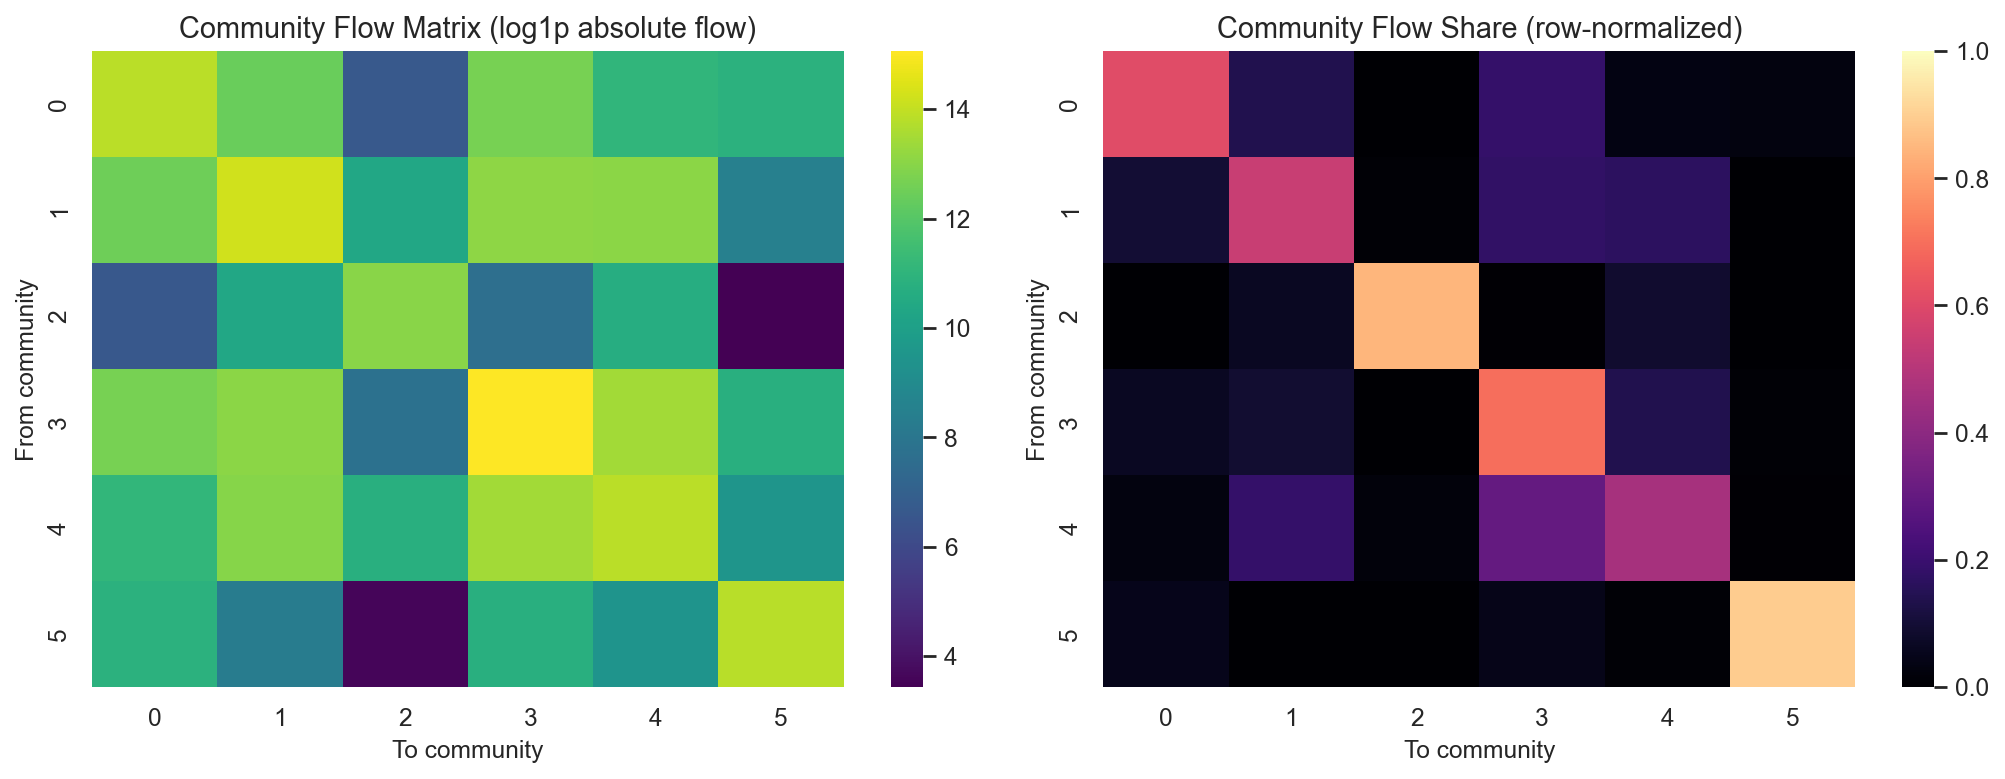

Saved figure: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\network\notebook\figures\community_flow_heatmaps.png
Saved table: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\network\notebook\community_flow_matrix.csv


In [30]:
community_flow_rows = []
for u, v, data in G.edges(data=True):
    cu = louvain_map.get(u)
    cv = louvain_map.get(v)
    if cu is None or cv is None:
        continue
    community_flow_rows.append(
        {
            'from_community': int(cu),
            'to_community': int(cv),
            'flow': float(data.get('flow', 0.0)),
        }
    )

community_flow_df = pd.DataFrame(community_flow_rows)
community_flow_matrix = (
    community_flow_df.groupby(['from_community', 'to_community'], as_index=False)['flow']
    .sum()
    .pivot(index='from_community', columns='to_community', values='flow')
    .fillna(0.0)
)

ordered = sorted(community_flow_matrix.index.tolist())
community_flow_matrix = community_flow_matrix.reindex(index=ordered, columns=ordered, fill_value=0.0)
community_flow_share = community_flow_matrix.div(
    community_flow_matrix.sum(axis=1).replace(0, np.nan), axis=0
).fillna(0.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(np.log1p(community_flow_matrix), cmap='viridis', ax=axes[0])
axes[0].set_title('Community Flow Matrix (log1p absolute flow)')
axes[0].set_xlabel('To community')
axes[0].set_ylabel('From community')

sns.heatmap(community_flow_share, cmap='magma', vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Community Flow Share (row-normalized)')
axes[1].set_xlabel('To community')
axes[1].set_ylabel('From community')

plt.tight_layout()
community_flow_fig = save_fig('community_flow_heatmaps.png')
plt.show()

community_flow_csv = NETWORK_OUT_DIR / 'community_flow_matrix.csv'
community_flow_matrix.to_csv(community_flow_csv)
print(f'Saved figure: {community_flow_fig}')
print(f'Saved table: {community_flow_csv}')

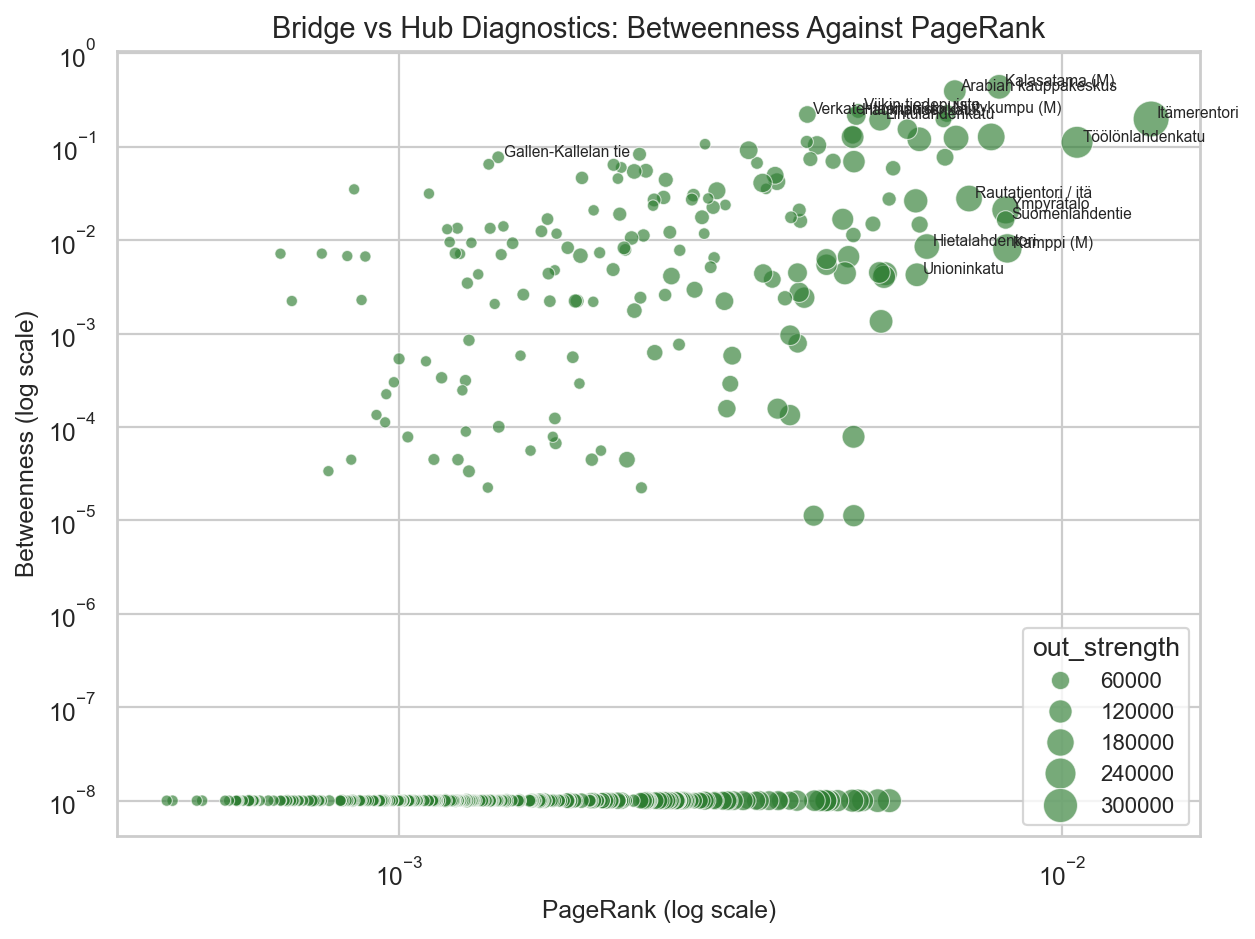

Saved figure: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\network\notebook\figures\bridge_vs_hub_scatter.png
Saved table: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\network\notebook\centrality_bridge_vs_hub.csv


In [31]:
diagnostics_df = centrality_df[
    ['station_name', 'pagerank', 'betweenness', 'out_strength', 'in_strength']
].copy()

for col in ['pagerank', 'betweenness', 'out_strength', 'in_strength']:
    diagnostics_df[f'z_{col}'] = (
        diagnostics_df[col] - diagnostics_df[col].mean()
    ) / (diagnostics_df[col].std(ddof=0) + 1e-12)

diagnostics_df['bridge_vs_popularity'] = (
    diagnostics_df['z_betweenness'] - diagnostics_df['z_pagerank']
)
diagnostics_df['pagerank_eps'] = diagnostics_df['pagerank'] + 1e-8
diagnostics_df['betweenness_eps'] = diagnostics_df['betweenness'] + 1e-8

label_df = pd.concat(
    [
        diagnostics_df.nlargest(8, 'bridge_vs_popularity'),
        diagnostics_df.nsmallest(8, 'bridge_vs_popularity'),
    ],
    axis=0,
).drop_duplicates(subset=['station_name'])

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=diagnostics_df,
    x='pagerank_eps',
    y='betweenness_eps',
    size='out_strength',
    sizes=(25, 260),
    alpha=0.65,
    color='#2E7D32',
    edgecolor='white',
    linewidth=0.5,
)

for _, row in label_df.iterrows():
    plt.text(
        row['pagerank_eps'] * 1.02,
        row['betweenness_eps'] * 1.02,
        row['station_name'],
        fontsize=7,
    )

plt.xscale('log')
plt.yscale('log')
plt.xlabel('PageRank (log scale)')
plt.ylabel('Betweenness (log scale)')
plt.title('Bridge vs Hub Diagnostics: Betweenness Against PageRank')
plt.tight_layout()
bridge_hub_fig = save_fig('bridge_vs_hub_scatter.png')
plt.show()

disagreement_csv = NETWORK_OUT_DIR / 'centrality_bridge_vs_hub.csv'
diagnostics_df.sort_values('bridge_vs_popularity', ascending=False).to_csv(disagreement_csv, index=False)
print(f'Saved figure: {bridge_hub_fig}')
print(f'Saved table: {disagreement_csv}')

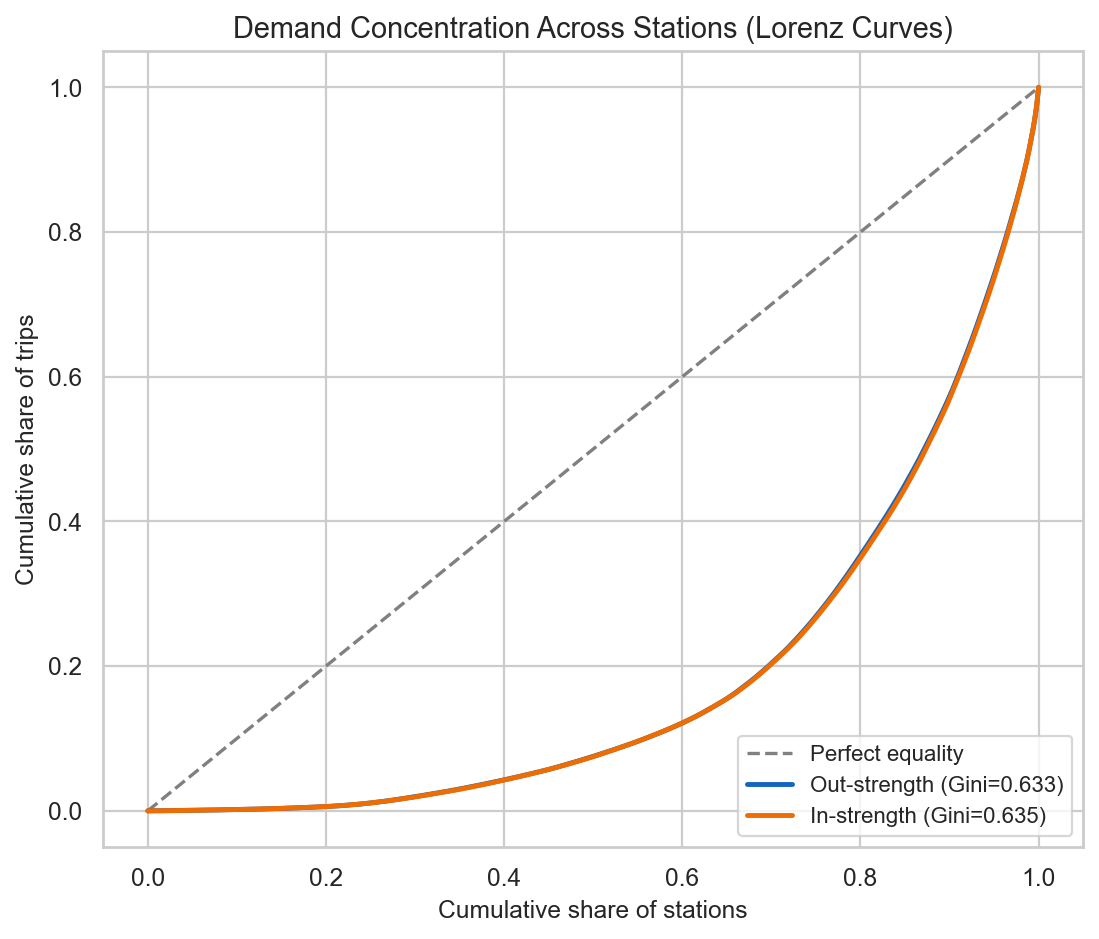

Saved figure: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\network\notebook\figures\demand_inequality_lorenz.png
Saved table: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\network\notebook\demand_inequality_lorenz_points.csv
Gini out-strength: 0.6325
Gini in-strength: 0.6346


In [32]:
def lorenz_curve_points(values: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    x = np.sort(np.asarray(values, dtype=float))
    if x.size == 0 or np.isclose(x.sum(), 0.0):
        p = np.linspace(0.0, 1.0, max(2, x.size + 1))
        return p, p
    cum = np.cumsum(x)
    lorenz = np.insert(cum / cum[-1], 0, 0.0)
    population = np.linspace(0.0, 1.0, x.size + 1)
    return population, lorenz


def gini_coefficient(values: np.ndarray) -> float:
    p, l = lorenz_curve_points(values)
    return float(1.0 - 2.0 * np.trapezoid(l, p))


p_out, l_out = lorenz_curve_points(centrality_df['out_strength'].to_numpy())
p_in, l_in = lorenz_curve_points(centrality_df['in_strength'].to_numpy())

gini_out = gini_coefficient(centrality_df['out_strength'].to_numpy())
gini_in = gini_coefficient(centrality_df['in_strength'].to_numpy())

plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect equality')
plt.plot(p_out, l_out, color='#1565C0', linewidth=2.2, label=f'Out-strength (Gini={gini_out:.3f})')
plt.plot(p_in, l_in, color='#EF6C00', linewidth=2.2, label=f'In-strength (Gini={gini_in:.3f})')
plt.xlabel('Cumulative share of stations')
plt.ylabel('Cumulative share of trips')
plt.title('Demand Concentration Across Stations (Lorenz Curves)')
plt.legend(loc='lower right')
plt.tight_layout()
lorenz_fig = save_fig('demand_inequality_lorenz.png')
plt.show()

lorenz_csv = NETWORK_OUT_DIR / 'demand_inequality_lorenz_points.csv'
pd.DataFrame(
    {
        'population_share': p_out,
        'out_strength_lorenz': l_out,
        'in_strength_lorenz': np.interp(p_out, p_in, l_in),
    }
).to_csv(lorenz_csv, index=False)

print(f'Saved figure: {lorenz_fig}')
print(f'Saved table: {lorenz_csv}')
print(f'Gini out-strength: {gini_out:.4f}')
print(f'Gini in-strength: {gini_in:.4f}')

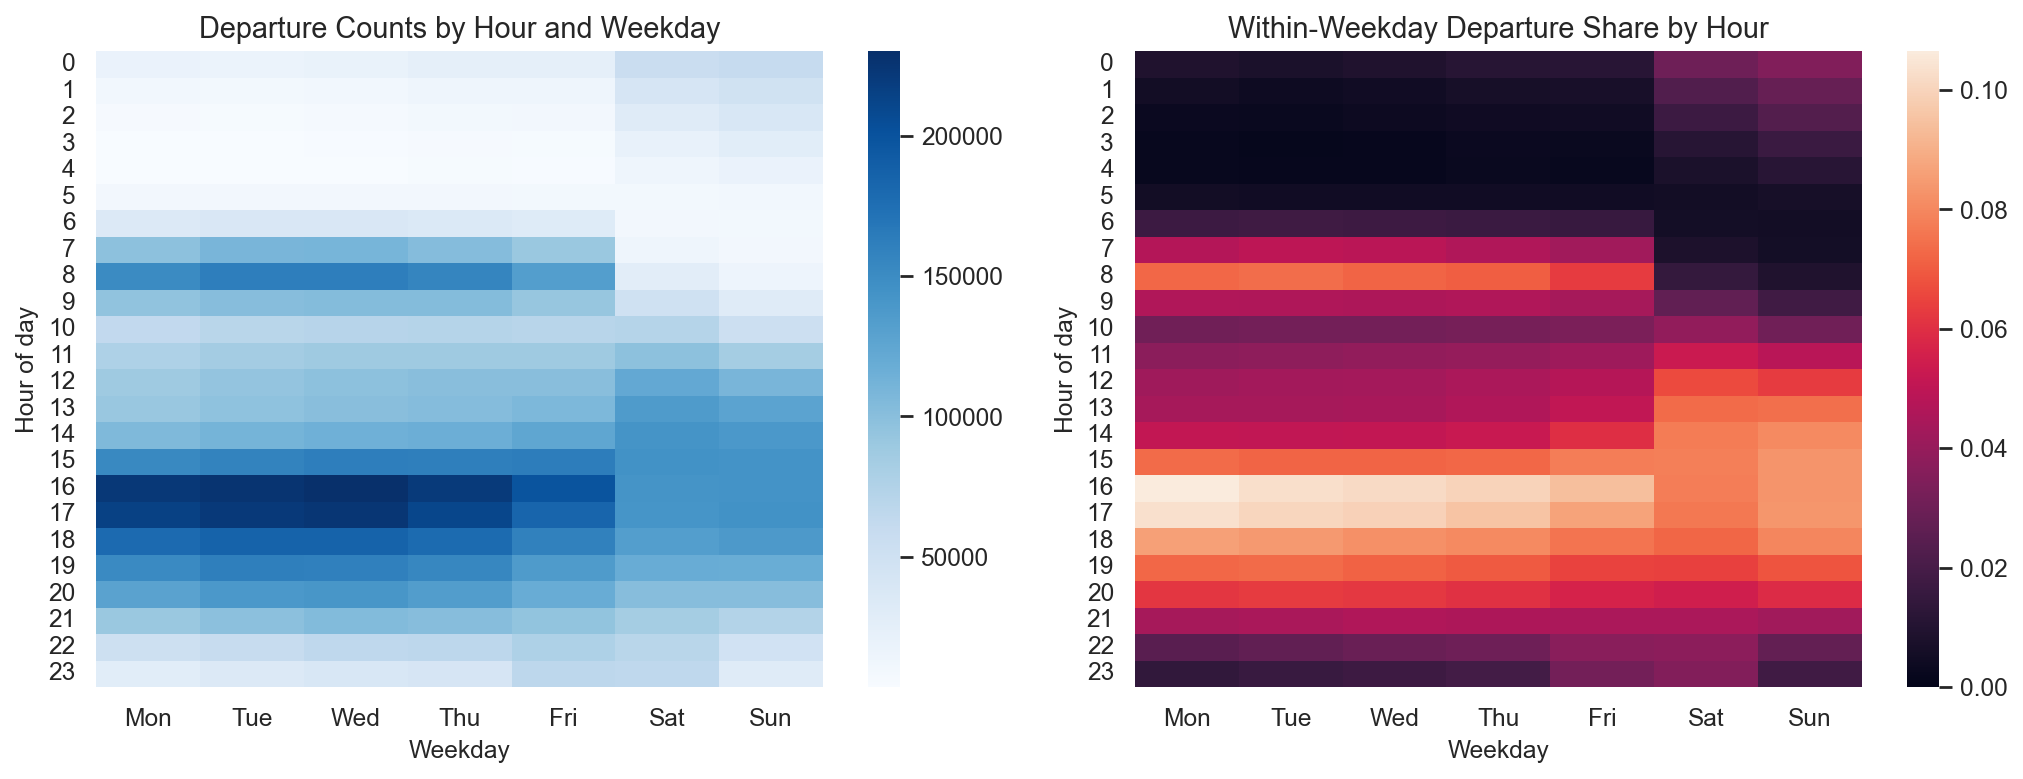

Saved figure: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\network\notebook\figures\temporal_signature_hour_weekday.png
Saved table: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\network\notebook\departure_hour_weekday_counts.csv


In [34]:
weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

hour_weekday_pl = (
    trips
    .select([
        pl.col('departure_ts').dt.hour().alias('hour'),
        pl.col('departure_ts').dt.strftime('%a').alias('weekday'),
    ])
    .group_by(['weekday', 'hour'])
    .len()
    .rename({'len': 'trips'})
)
hour_weekday_df = pd.DataFrame(hour_weekday_pl.to_dicts())

hour_weekday_pivot = (
    hour_weekday_df
    .pivot(index='hour', columns='weekday', values='trips')
    .reindex(index=list(range(24)), columns=weekday_order)
    .fillna(0.0)
)
hour_weekday_share = hour_weekday_pivot.div(
    hour_weekday_pivot.sum(axis=0).replace(0, np.nan), axis=1
).fillna(0.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(hour_weekday_pivot, cmap='Blues', ax=axes[0])
axes[0].set_title('Departure Counts by Hour and Weekday')
axes[0].set_xlabel('Weekday')
axes[0].set_ylabel('Hour of day')

sns.heatmap(hour_weekday_share, cmap='rocket', vmin=0, vmax=hour_weekday_share.to_numpy().max(), ax=axes[1])
axes[1].set_title('Within-Weekday Departure Share by Hour')
axes[1].set_xlabel('Weekday')
axes[1].set_ylabel('Hour of day')

plt.tight_layout()
temporal_fig = save_fig('temporal_signature_hour_weekday.png')
plt.show()

temporal_csv = NETWORK_OUT_DIR / 'departure_hour_weekday_counts.csv'
hour_weekday_pivot.to_csv(temporal_csv)
print(f'Saved figure: {temporal_fig}')
print(f'Saved table: {temporal_csv}')

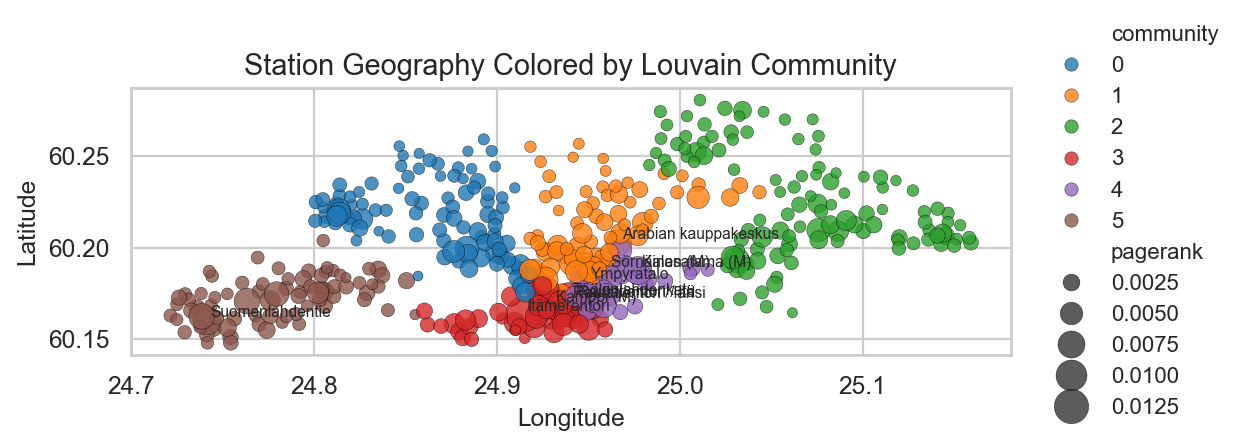

Saved figure: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\network\notebook\figures\community_geographic_map.png
Saved table: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\network\notebook\station_community_coordinates.csv


In [35]:
coord_required = {
    'departure_name',
    'departure_latitude',
    'departure_longitude',
    'return_name',
    'return_latitude',
    'return_longitude',
}

if coord_required.issubset(set(trips.columns)):
    dep_coords = trips.select(
        [
            pl.col('departure_name').alias('station_name'),
            pl.col('departure_latitude').cast(pl.Float64).alias('latitude'),
            pl.col('departure_longitude').cast(pl.Float64).alias('longitude'),
        ]
    )
    ret_coords = trips.select(
        [
            pl.col('return_name').alias('station_name'),
            pl.col('return_latitude').cast(pl.Float64).alias('latitude'),
            pl.col('return_longitude').cast(pl.Float64).alias('longitude'),
        ]
    )

    station_coords_pl = (
        pl.concat([dep_coords, ret_coords], how='vertical_relaxed')
        .drop_nulls(['station_name', 'latitude', 'longitude'])
        .group_by('station_name')
        .agg(
            [
                pl.col('latitude').mean().alias('latitude'),
                pl.col('longitude').mean().alias('longitude'),
            ]
        )
    )
    station_coords_df = pd.DataFrame(station_coords_pl.to_dicts())

    community_lookup_df = pd.DataFrame(
        [(station, cid) for station, cid in louvain_map.items()],
        columns=['station_name', 'community'],
    )

    map_df = (
        station_coords_df
        .merge(community_lookup_df, on='station_name', how='left')
        .merge(centrality_df[['station_name', 'pagerank']], on='station_name', how='left')
    )

    plt.figure(figsize=(8, 8))
    sns.scatterplot(
        data=map_df,
        x='longitude',
        y='latitude',
        hue='community',
        size='pagerank',
        sizes=(20, 260),
        alpha=0.8,
        palette='tab10',
        linewidth=0.2,
        edgecolor='black',
    )

    for _, row in map_df.nlargest(10, 'pagerank').iterrows():
        plt.text(row['longitude'] + 0.002, row['latitude'] + 0.002, row['station_name'], fontsize=7)

    plt.title('Station Geography Colored by Louvain Community')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
    plt.tight_layout()
    community_geo_fig = save_fig('community_geographic_map.png')
    plt.show()

    map_csv = NETWORK_OUT_DIR / 'station_community_coordinates.csv'
    map_df.to_csv(map_csv, index=False)
    print(f'Saved figure: {community_geo_fig}')
    print(f'Saved table: {map_csv}')
else:
    print('Skipping geographic map: coordinate columns are not available in the selected trips dataset.')

## Multi-Graph Comparative Analysis (SD, DE, DC, ATD)

This section compares the precomputed graph views from data/artifacts/graphs/train and answers:

1. How their structural properties differ
2. Whether important stations are stable across graph definitions
3. Whether communities agree across graph definitions
4. How much edge-level agreement exists across graph views

Interpretation note: for comparability, we analyze graph backbones built from the strongest edges in each matrix (quantile filtering).

In [47]:
GRAPH_DIR = ARTIFACTS_DIR / 'graphs' / 'train'
MATRIX_FILES = {
    'SD': GRAPH_DIR / 'SD.npy',
    'DE': GRAPH_DIR / 'DE.npy',
    'DC': GRAPH_DIR / 'DC.npy',
    'ATD': GRAPH_DIR / 'ATD.npy',
}
STATION_INDEX_PATH = GRAPH_DIR / 'station_index.txt'

if 'FIG_DIR' not in globals():
    FIG_DIR = NETWORK_OUT_DIR / 'figures'
    FIG_DIR.mkdir(parents=True, exist_ok=True)

if 'save_fig' not in globals():
    def save_fig(filename: str):
        out = FIG_DIR / filename
        plt.savefig(out, bbox_inches='tight')
        return out

missing = [str(path) for path in [STATION_INDEX_PATH, *MATRIX_FILES.values()] if not path.exists()]
if missing:
    raise FileNotFoundError(f'Missing precomputed graph artifacts: {missing}')

station_names = [line.strip() for line in STATION_INDEX_PATH.read_text(encoding='utf-8').splitlines() if line.strip()]
matrices = {name: np.load(path) for name, path in MATRIX_FILES.items()}

n = len(station_names)
for name, mat in matrices.items():
    if mat.shape != (n, n):
        raise ValueError(f'{name} matrix shape {mat.shape} does not match station index size {n}.')

matrix_summary = pd.DataFrame(
    {
        'graph': list(matrices.keys()),
        'shape': [str(m.shape) for m in matrices.values()],
        'nonzero_edges': [int((m > 0).sum()) for m in matrices.values()],
        'density': [float((m > 0).sum() / (m.size - n)) for m in matrices.values()],
    }
)

matrix_summary

,graph,shape,nonzero_edges,density
0,SD,"(449, 449)",6474,0.032185
1,DE,"(449, 449)",80442,0.399907
2,DC,"(449, 449)",199330,0.990942
3,ATD,"(449, 449)",80442,0.399907


### Structural Comparison

We convert each matrix into a backbone graph using graph-specific edge-strength quantiles, then compare key structural metrics.

How to read:

1. Edge count and density indicate sparsity/connectedness
2. Giant component ratio indicates network cohesion
3. Modularity and community count indicate segmentation strength
4. Reciprocity is only meaningful for directed graphs (DE, ATD)

In [37]:
GRAPH_SPECS = {
    'SD': {'directed': False, 'quantile': 0.85},
    'DE': {'directed': True, 'quantile': 0.90},
    'DC': {'directed': False, 'quantile': 0.90},
    'ATD': {'directed': True, 'quantile': 0.90},
}


def build_backbone_matrix(matrix: np.ndarray, quantile: float) -> np.ndarray:
    m = np.array(matrix, copy=True, dtype=float)
    np.fill_diagonal(m, 0.0)
    nz = m[m > 0]
    if nz.size == 0:
        return m
    threshold = np.quantile(nz, quantile)
    m = np.where(m >= threshold, m, 0.0)
    np.fill_diagonal(m, 0.0)
    return m


def matrix_to_graph(matrix: np.ndarray, labels: list[str], directed: bool) -> nx.Graph | nx.DiGraph:
    g = nx.DiGraph() if directed else nx.Graph()
    g.add_nodes_from(labels)

    if directed:
        rows, cols = np.where(matrix > 0)
        for i, j in zip(rows, cols):
            if i == j:
                continue
            w = float(matrix[i, j])
            g.add_edge(labels[i], labels[j], weight=w, cost=1.0 / (w + 1e-12))
    else:
        tri_i, tri_j = np.triu_indices_from(matrix, k=1)
        for i, j in zip(tri_i, tri_j):
            w = float(max(matrix[i, j], matrix[j, i]))
            if w <= 0:
                continue
            g.add_edge(labels[i], labels[j], weight=w, cost=1.0 / (w + 1e-12))

    return g


def summarize_graph(g: nx.Graph | nx.DiGraph, seed: int = 42) -> dict:
    n_nodes = g.number_of_nodes()
    n_edges = g.number_of_edges()
    density = nx.density(g)

    if isinstance(g, nx.DiGraph):
        comps = list(nx.weakly_connected_components(g))
        reciprocity = nx.reciprocity(g)
        ug = g.to_undirected()
    else:
        comps = list(nx.connected_components(g)) if n_nodes > 0 else []
        reciprocity = np.nan
        ug = g

    giant_ratio = (max((len(c) for c in comps), default=0) / n_nodes) if n_nodes > 0 else 0.0
    avg_clustering = nx.average_clustering(ug, weight='weight') if ug.number_of_edges() > 0 else 0.0

    if ug.number_of_edges() > 0:
        comms = nx.community.louvain_communities(ug, weight='weight', seed=seed)
        modularity = nx.community.modularity(ug, comms, weight='weight')
        community_count = len(comms)
    else:
        modularity = 0.0
        community_count = 0

    return {
        'nodes': n_nodes,
        'edges': n_edges,
        'density': float(density),
        'giant_component_ratio': float(giant_ratio),
        'avg_clustering': float(avg_clustering),
        'modularity': float(modularity),
        'community_count': int(community_count),
        'reciprocity': float(reciprocity) if reciprocity is not None else np.nan,
    }


backbone_matrices = {
    name: build_backbone_matrix(matrices[name], GRAPH_SPECS[name]['quantile'])
    for name in matrices
}
comparison_graphs = {
    name: matrix_to_graph(backbone_matrices[name], station_names, GRAPH_SPECS[name]['directed'])
    for name in matrices
}

structural_df = pd.DataFrame(
    [
        {'graph': name, **summarize_graph(graph, seed=RANDOM_STATE)}
        for name, graph in comparison_graphs.items()
    ]
).set_index('graph')

structural_df

,nodes,edges,density,giant_component_ratio,avg_clustering,modularity,community_count,reciprocity
graph,,,,,,,,
SD,449,777,0.007726,0.289532,0.288548,0.907833,93,NaN
DE,449,8045,0.039995,1.000000,0.023958,0.735225,9,0.575513
DC,449,9967,0.099099,0.710468,0.357203,0.240242,135,NaN
ATD,449,8045,0.039995,0.995546,0.031492,0.672856,8,0.496209


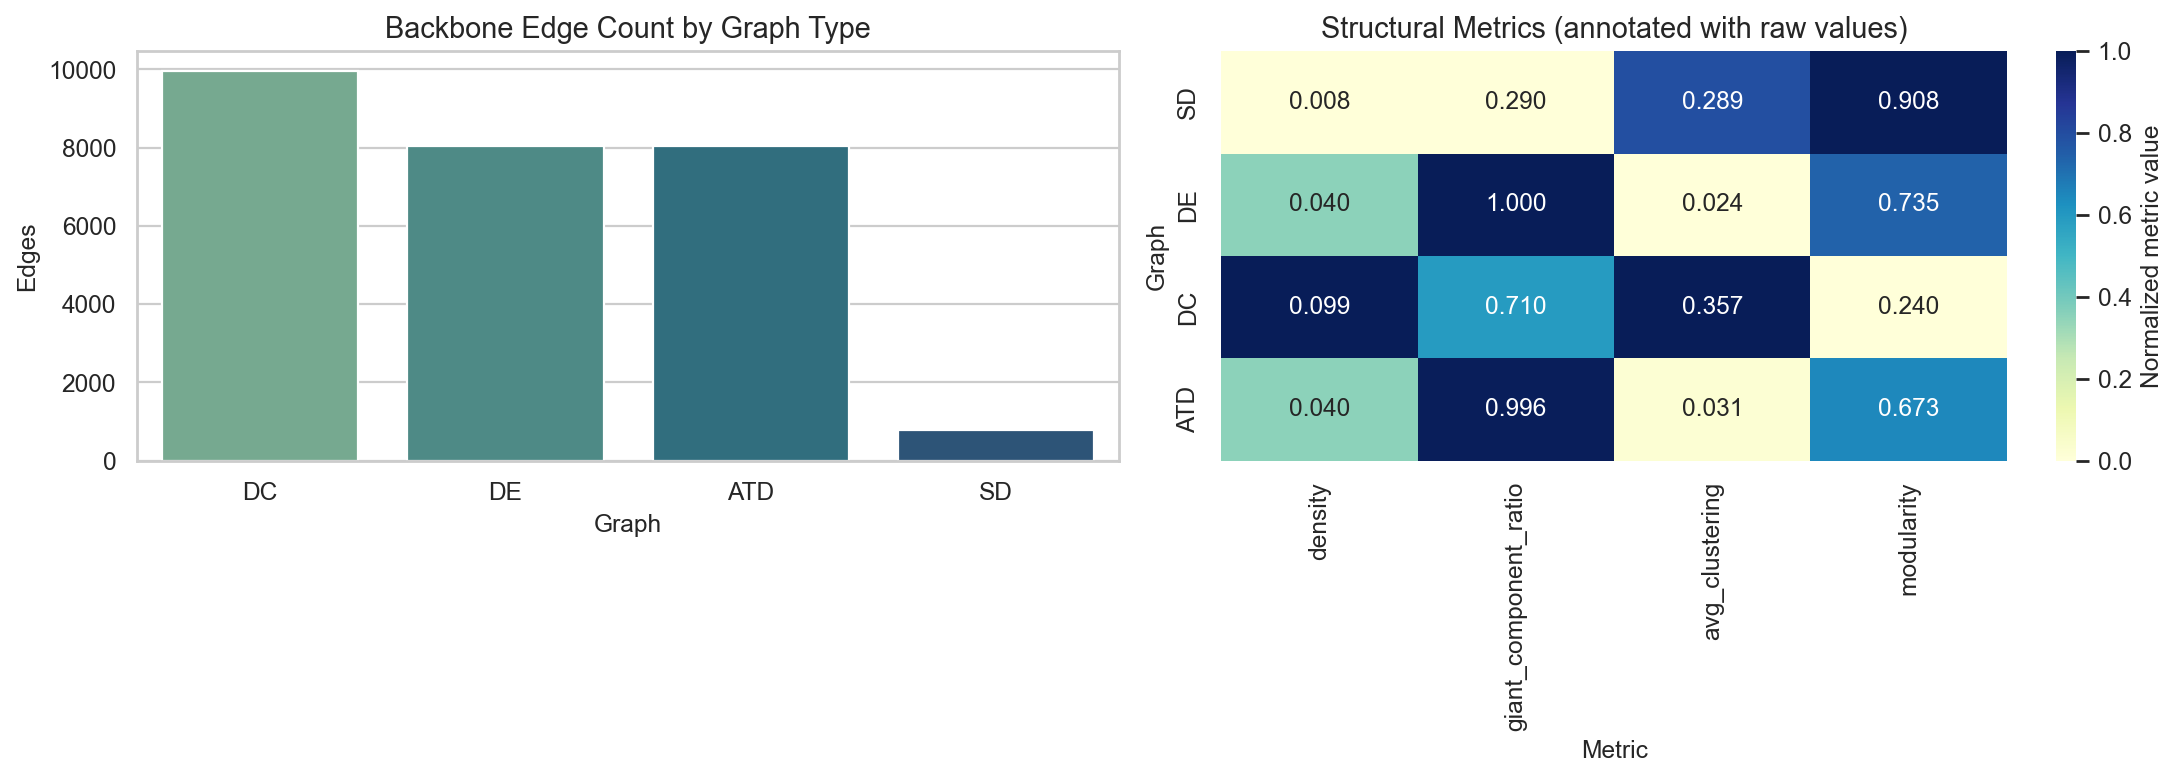

Saved figure: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\network\notebook\figures\multigraph_structural_comparison.png
Saved table: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\network\notebook\multigraph_structural_metrics.csv


In [44]:
plot_metrics = ['density', 'giant_component_ratio', 'avg_clustering', 'modularity']
plot_data = structural_df[plot_metrics]
plot_norm = (plot_data - plot_data.min()) / (plot_data.max() - plot_data.min() + 1e-12)
annot_values = np.vectorize(lambda x: f'{x:.3f}')(plot_data.to_numpy())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

edge_plot_df = structural_df.reset_index()[['graph', 'edges']].sort_values('edges', ascending=False)
sns.barplot(
    data=edge_plot_df,
    x='graph',
    y='edges',
    hue='graph',
    palette='crest',
    legend=False,
    ax=axes[0],
)
axes[0].set_title('Backbone Edge Count by Graph Type')
axes[0].set_xlabel('Graph')
axes[0].set_ylabel('Edges')

sns.heatmap(
    plot_norm,
    annot=annot_values,
    fmt='',
    cmap='YlGnBu',
    cbar_kws={'label': 'Normalized metric value'},
    ax=axes[1],
)
axes[1].set_title('Structural Metrics (annotated with raw values)')
axes[1].set_xlabel('Metric')
axes[1].set_ylabel('Graph')

plt.tight_layout()
structural_fig = save_fig('multigraph_structural_comparison.png')
plt.show()

structural_csv = NETWORK_OUT_DIR / 'multigraph_structural_metrics.csv'
structural_df.to_csv(structural_csv)
print(f'Saved figure: {structural_fig}')
print(f'Saved table: {structural_csv}')

### Node Role Stability Across Graph Definitions

This comparison checks whether top stations are robust to graph definition.

How to read:

1. The heatmap shows Spearman rank correlation between PageRank vectors from each graph
2. The consensus hub ranking rewards stations that rank highly across all graphs

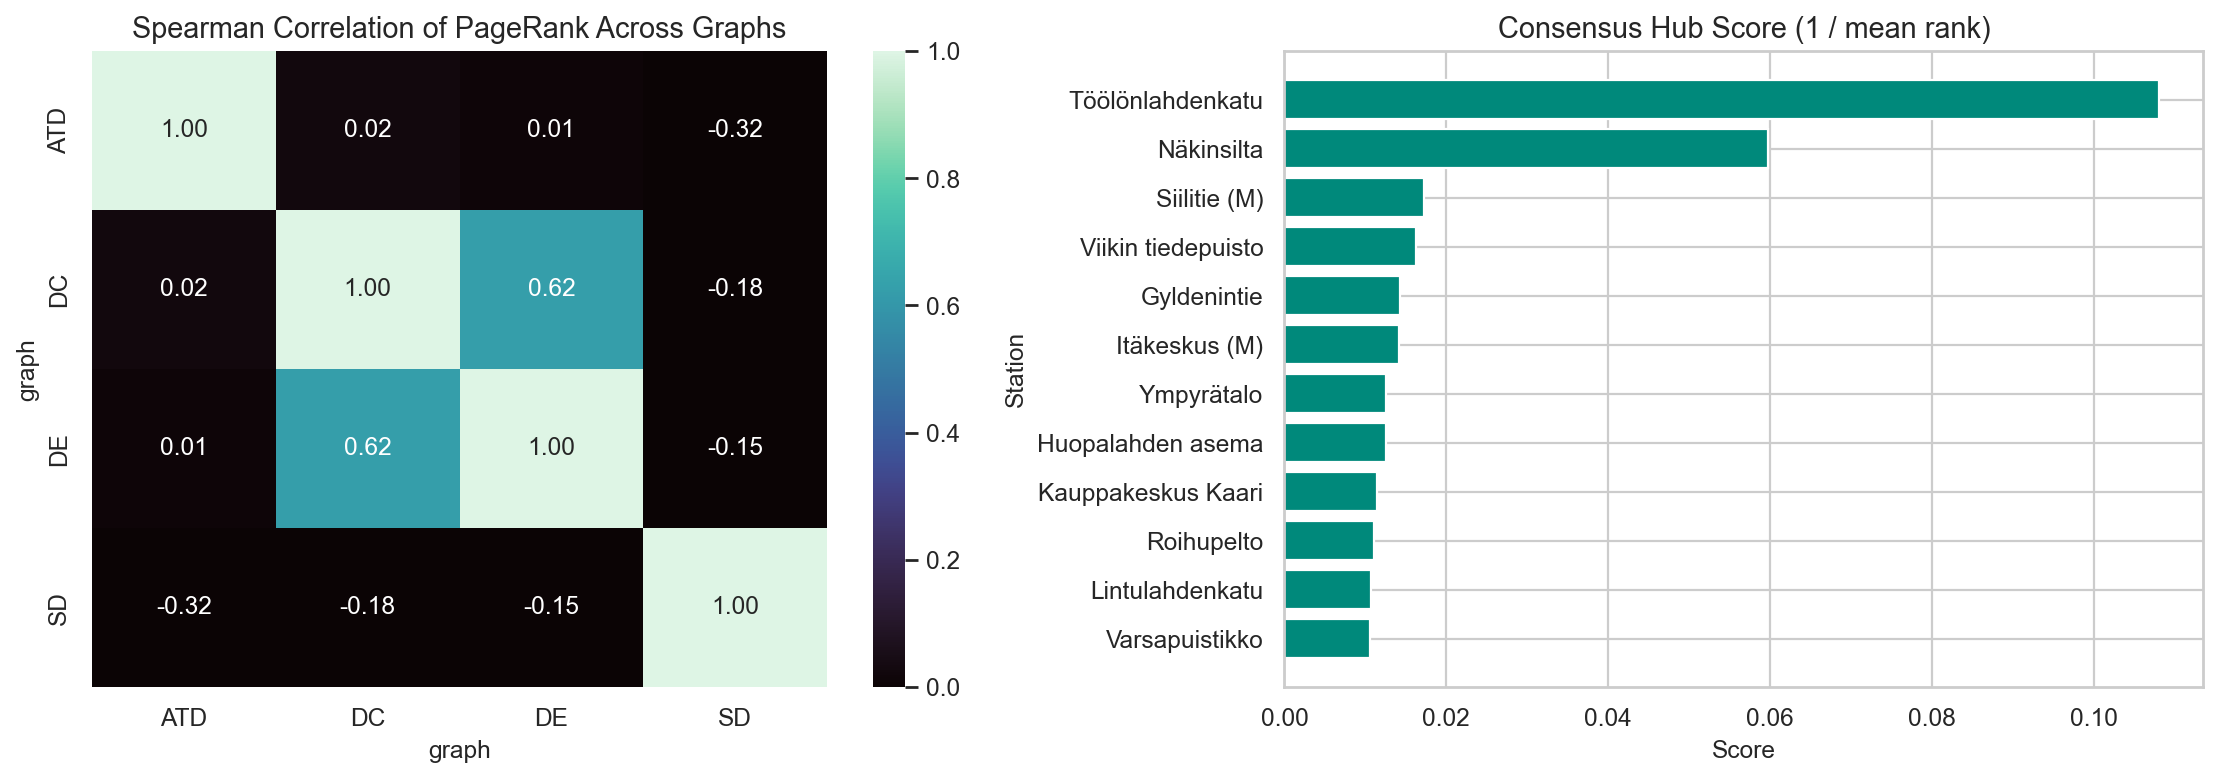

Saved figure: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\network\notebook\figures\multigraph_role_stability.png
Saved table: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\network\notebook\multigraph_pagerank_rank_correlation.csv
Saved table: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\network\notebook\multigraph_consensus_hubs.csv


,mean_rank,std_rank
station_name,,
Töölönlahdenkatu,9.25,8.958236
Näkinsilta,16.75,15.777093
Siilitie (M),58.00,27.055499
Viikin tiedepuisto,61.50,36.864617
Gyldenintie,70.25,46.721694
Itäkeskus (M),70.75,51.057974
Ympyrätalo,79.50,85.340494
Huopalahden asema,79.75,36.664015
Kauppakeskus Kaari,87.00,71.856338


In [40]:
role_rows = []
for graph_name, graph in comparison_graphs.items():
    ug = graph.to_undirected() if isinstance(graph, nx.DiGraph) else graph

    if graph.number_of_edges() > 0:
        pr = nx.pagerank(graph, weight='weight')
    else:
        pr = {n: 0.0 for n in graph.nodes()}

    if ug.number_of_edges() > 0:
        bw_k = min(200, max(10, ug.number_of_nodes() // 2))
        bw = nx.betweenness_centrality(ug, k=bw_k, seed=RANDOM_STATE, weight='cost', normalized=True)
    else:
        bw = {n: 0.0 for n in ug.nodes()}

    for station in station_names:
        role_rows.append(
            {
                'station_name': station,
                'graph': graph_name,
                'pagerank': float(pr.get(station, 0.0)),
                'betweenness': float(bw.get(station, 0.0)),
            }
        )

role_df = pd.DataFrame(role_rows)
pagerank_pivot = role_df.pivot(index='station_name', columns='graph', values='pagerank').fillna(0.0)
rank_corr = pagerank_pivot.corr(method='spearman')

rank_table = pagerank_pivot.rank(ascending=False, method='average')
consensus_hubs = (
    pd.DataFrame(
        {
            'mean_rank': rank_table.mean(axis=1),
            'std_rank': rank_table.std(axis=1),
        }
    )
    .sort_values(['mean_rank', 'std_rank'])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(rank_corr, annot=True, fmt='.2f', vmin=0, vmax=1, cmap='mako', ax=axes[0])
axes[0].set_title('Spearman Correlation of PageRank Across Graphs')

hub_plot = consensus_hubs.head(12).sort_values('mean_rank', ascending=False)
axes[1].barh(hub_plot.index, 1.0 / hub_plot['mean_rank'], color='#00897B')
axes[1].set_title('Consensus Hub Score (1 / mean rank)')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Station')

plt.tight_layout()
role_fig = save_fig('multigraph_role_stability.png')
plt.show()

rank_corr_csv = NETWORK_OUT_DIR / 'multigraph_pagerank_rank_correlation.csv'
rank_corr.to_csv(rank_corr_csv)
consensus_csv = NETWORK_OUT_DIR / 'multigraph_consensus_hubs.csv'
consensus_hubs.to_csv(consensus_csv)

print(f'Saved figure: {role_fig}')
print(f'Saved table: {rank_corr_csv}')
print(f'Saved table: {consensus_csv}')
consensus_hubs.head(15)

### Community Agreement Across Graph Definitions

We run Louvain on each graph backbone and compare partitions with normalized mutual information (NMI).

How to read:

1. NMI near 1 means very similar community assignments
2. Lower NMI indicates each graph captures a different structural signal

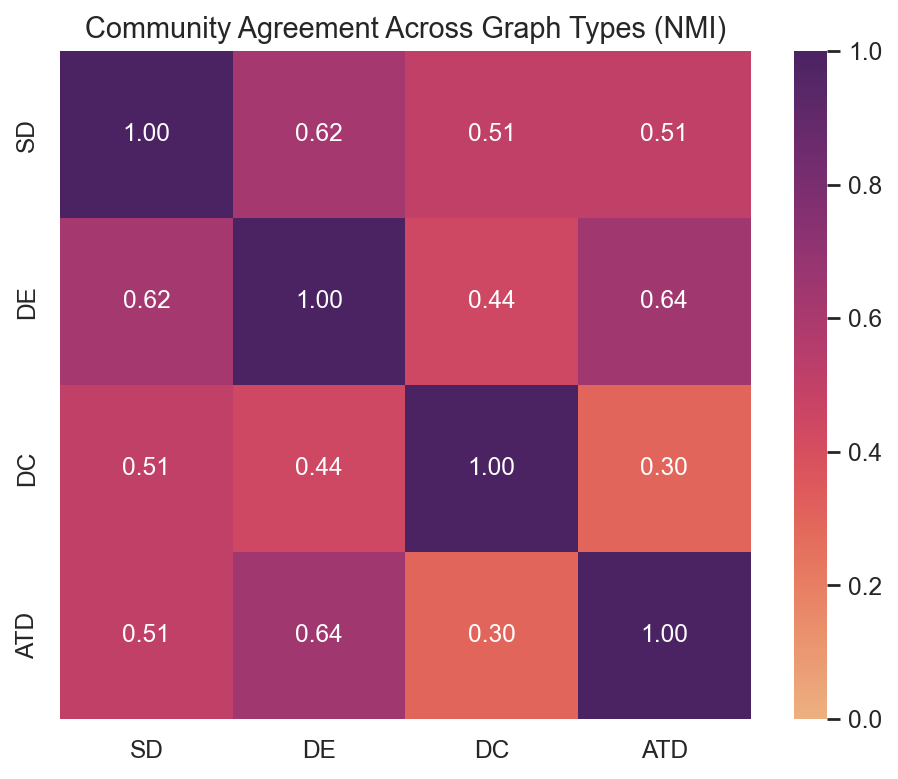

Saved figure: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\network\notebook\figures\multigraph_community_nmi.png
Saved table: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\network\notebook\multigraph_community_nmi.csv


,SD,DE,DC,ATD
SD,1.000000,0.624209,0.510659,0.505689
DE,0.624209,1.000000,0.442189,0.639168
DC,0.510659,0.442189,1.000000,0.298161
ATD,0.505689,0.639168,0.298161,1.000000


In [41]:
from sklearn.metrics import normalized_mutual_info_score

partitions = {}
for graph_name, graph in comparison_graphs.items():
    ug = graph.to_undirected() if isinstance(graph, nx.DiGraph) else graph
    if ug.number_of_edges() == 0:
        partitions[graph_name] = {node: i for i, node in enumerate(station_names)}
        continue

    comms = nx.community.louvain_communities(ug, weight='weight', seed=RANDOM_STATE)
    cmap = {}
    for cid, nodes in enumerate(comms):
        for node in nodes:
            cmap[node] = cid

    for node in station_names:
        if node not in cmap:
            cmap[node] = -1
    partitions[graph_name] = cmap

graph_order = list(partitions.keys())
nmi_matrix = pd.DataFrame(index=graph_order, columns=graph_order, dtype=float)

for g1 in graph_order:
    for g2 in graph_order:
        labels1 = [partitions[g1][node] for node in station_names]
        labels2 = [partitions[g2][node] for node in station_names]
        nmi_matrix.loc[g1, g2] = normalized_mutual_info_score(labels1, labels2)

plt.figure(figsize=(6, 5))
sns.heatmap(nmi_matrix, annot=True, fmt='.2f', vmin=0, vmax=1, cmap='flare')
plt.title('Community Agreement Across Graph Types (NMI)')
plt.tight_layout()
nmi_fig = save_fig('multigraph_community_nmi.png')
plt.show()

nmi_csv = NETWORK_OUT_DIR / 'multigraph_community_nmi.csv'
nmi_matrix.to_csv(nmi_csv)
print(f'Saved figure: {nmi_fig}')
print(f'Saved table: {nmi_csv}')
nmi_matrix

### Edge Agreement and Distance-Demand Relationship

This block quantifies how similar the strongest links are across graph types and checks whether spatial affinity (SD) aligns with demand links (DE).

How to read:

1. Jaccard overlap near 1 means two graph views prioritize similar strongest edges
2. Positive SD-DE association suggests geographic closeness supports demand connectivity

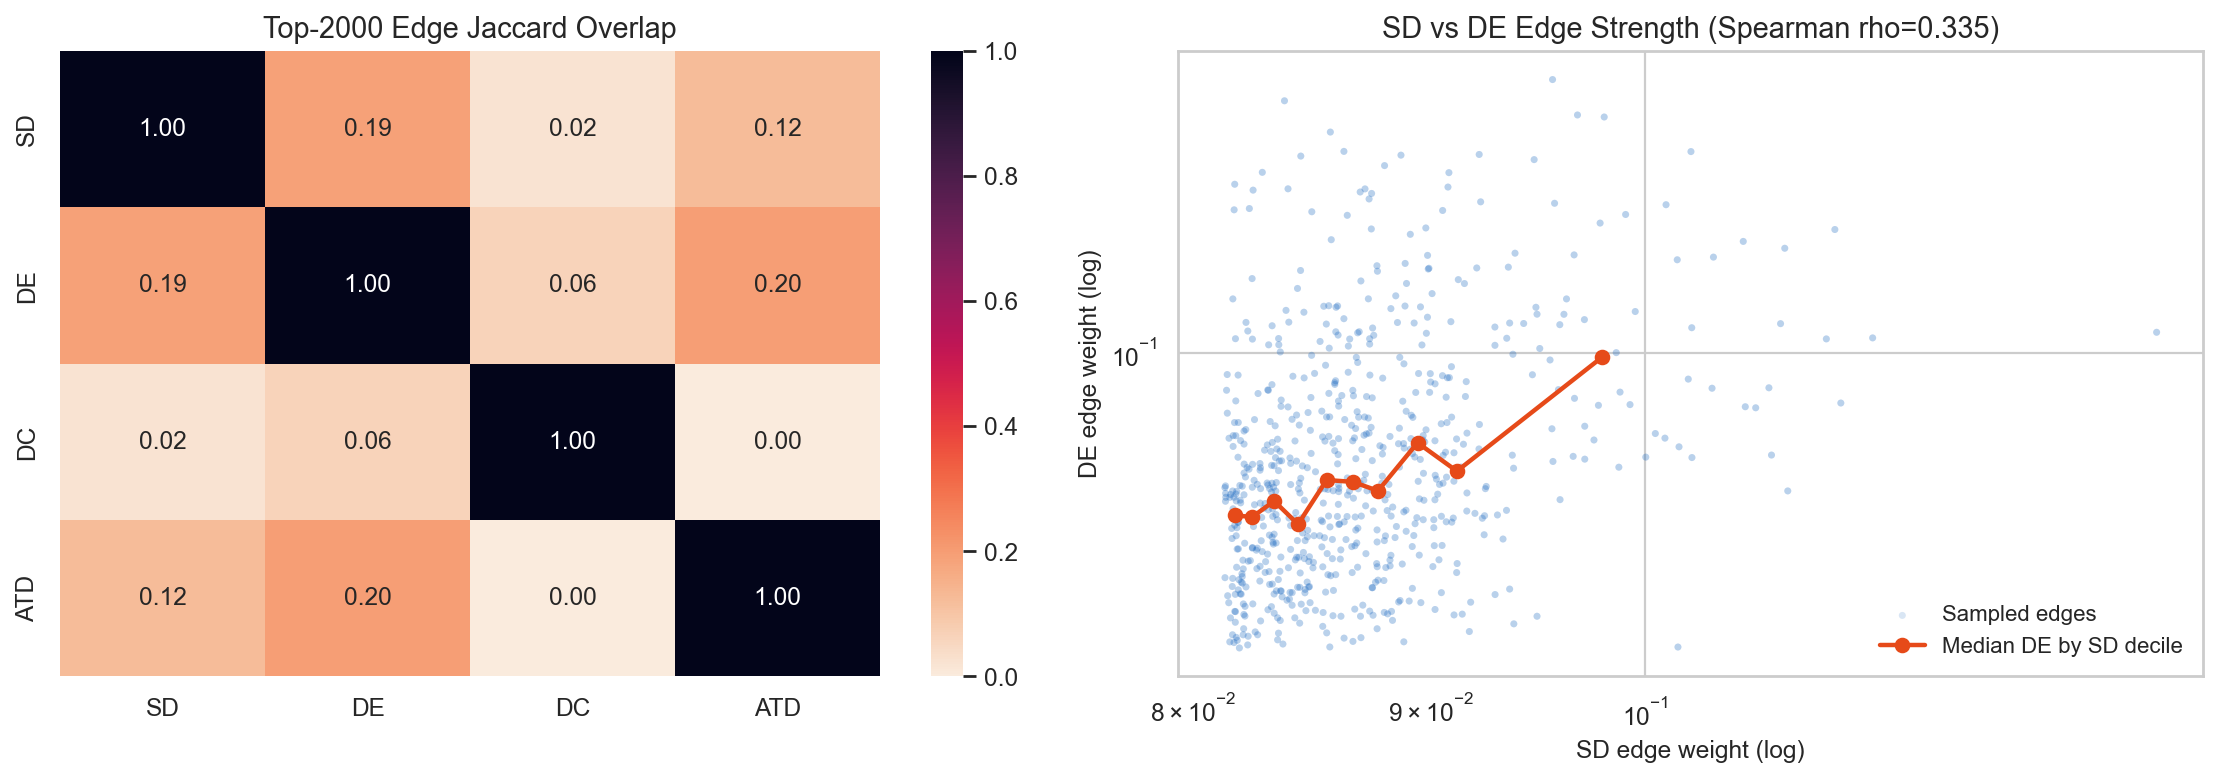

Saved figure: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\network\notebook\figures\multigraph_edge_overlap_and_sd_de_relationship.png
Saved table: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\network\notebook\multigraph_edge_jaccard.csv
Saved table: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\network\notebook\sd_de_edge_relationship.csv
Saved table: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\network\notebook\sd_de_edge_relationship_deciles.csv


In [43]:
def symmetrize_for_overlap(matrix: np.ndarray) -> np.ndarray:
    m = np.array(matrix, copy=True, dtype=float)
    np.fill_diagonal(m, 0.0)
    return np.maximum(m, m.T)


def top_k_edge_set(matrix: np.ndarray, k: int) -> set[tuple[int, int]]:
    tri_i, tri_j = np.triu_indices_from(matrix, k=1)
    weights = matrix[tri_i, tri_j]
    valid = np.where(weights > 0)[0]
    if valid.size == 0:
        return set()

    if valid.size > k:
        top_idx = valid[np.argpartition(weights[valid], -k)[-k:]]
    else:
        top_idx = valid

    return {(int(tri_i[idx]), int(tri_j[idx])) for idx in top_idx}


sym_mats = {name: symmetrize_for_overlap(backbone_matrices[name]) for name in backbone_matrices}

top_k = 2000
edge_sets = {name: top_k_edge_set(sym_mats[name], k=top_k) for name in sym_mats}

jaccard = pd.DataFrame(index=sym_mats.keys(), columns=sym_mats.keys(), dtype=float)
for g1 in sym_mats:
    for g2 in sym_mats:
        a, b = edge_sets[g1], edge_sets[g2]
        jaccard.loc[g1, g2] = len(a & b) / max(1, len(a | b))

sd = sym_mats['SD']
de = sym_mats['DE']
mask = (sd > 0) & (de > 0)
x = sd[mask]
y = de[mask]

sd_de_df = pd.DataFrame({'sd_weight': x, 'de_weight': y})
sd_de_rho = sd_de_df['sd_weight'].corr(sd_de_df['de_weight'], method='spearman') if not sd_de_df.empty else np.nan

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(jaccard, annot=True, fmt='.2f', vmin=0, vmax=1, cmap='rocket_r', ax=axes[0])
axes[0].set_title(f'Top-{top_k} Edge Jaccard Overlap')

if sd_de_df.empty:
    axes[1].text(0.5, 0.5, 'No overlapping positive SD and DE edges', ha='center', va='center')
    axes[1].set_axis_off()
    trend_df = pd.DataFrame(columns=['sd_mid', 'de_median', 'count'])
else:
    sample_n = min(15000, len(sd_de_df))
    sample_df = sd_de_df.sample(sample_n, random_state=RANDOM_STATE)
    axes[1].scatter(
        sample_df['sd_weight'],
        sample_df['de_weight'],
        s=10,
        alpha=0.16,
        color='#1565C0',
        edgecolors='none',
        label='Sampled edges',
    )

    sd_bins = pd.qcut(sd_de_df['sd_weight'], q=10, duplicates='drop')
    trend_df = (
        sd_de_df
        .groupby(sd_bins)
        .agg(sd_mid=('sd_weight', 'median'), de_median=('de_weight', 'median'), count=('de_weight', 'size'))
        .reset_index(drop=True)
    )

    axes[1].plot(
        trend_df['sd_mid'],
        trend_df['de_median'],
        color='#E64A19',
        marker='o',
        linewidth=2,
        label='Median DE by SD decile',
    )

    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].set_xlabel('SD edge weight (log)')
    axes[1].set_ylabel('DE edge weight (log)')
    axes[1].set_title(f'SD vs DE Edge Strength (Spearman rho={sd_de_rho:.3f})')
    axes[1].legend(frameon=False, loc='lower right')

plt.tight_layout()
overlap_fig = save_fig('multigraph_edge_overlap_and_sd_de_relationship.png')
plt.show()

jaccard_csv = NETWORK_OUT_DIR / 'multigraph_edge_jaccard.csv'
jaccard.to_csv(jaccard_csv)
sd_de_csv = NETWORK_OUT_DIR / 'sd_de_edge_relationship.csv'
sd_de_df.to_csv(sd_de_csv, index=False)
sd_de_trend_csv = NETWORK_OUT_DIR / 'sd_de_edge_relationship_deciles.csv'
trend_df.to_csv(sd_de_trend_csv, index=False)

print(f'Saved figure: {overlap_fig}')
print(f'Saved table: {jaccard_csv}')
print(f'Saved table: {sd_de_csv}')
print(f'Saved table: {sd_de_trend_csv}')

## Export Artifacts

In [28]:
centrality_path = NETWORK_OUT_DIR / 'node_metrics.csv'
community_path = NETWORK_OUT_DIR / 'communities.csv'
community_summary_path = NETWORK_OUT_DIR / 'community_summary.csv'
stability_path = NETWORK_OUT_DIR / 'partition_stability.csv'

centrality_df.to_csv(centrality_path, index=False)

communities_df = pd.DataFrame(
    [(station, cid) for station, cid in louvain_map.items()],
    columns=['station_name', 'community']
).sort_values(['community', 'station_name'])
communities_df.to_csv(community_path, index=False)

community_summary_rows = []
for cid in sorted(set(louvain_map.values())):
    members = {n for n, g in louvain_map.items() if g == cid}
    internal_flow = outgoing_flow = incoming_flow = 0.0
    for u, v, data in G.edges(data=True):
        w = float(data.get('flow', 0.0))
        if u in members and v in members:
            internal_flow += w
        elif u in members and v not in members:
            outgoing_flow += w
        elif u not in members and v in members:
            incoming_flow += w
    community_summary_rows.append({
        'community': cid,
        'stations': len(members),
        'internal_flow': internal_flow,
        'outgoing_flow': outgoing_flow,
        'incoming_flow': incoming_flow,
    })

pd.DataFrame(community_summary_rows).sort_values('stations', ascending=False).to_csv(community_summary_path, index=False)

if not stability_df.empty:
    stability_df.to_csv(stability_path, index=False)

print(f'Saved node metrics: {centrality_path}')
print(f'Saved communities: {community_path}')
print(f'Saved community summary: {community_summary_path}')
if not stability_df.empty:
    print(f'Saved temporal stability: {stability_path}')

Saved node metrics: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\network\notebook\node_metrics.csv
Saved communities: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\network\notebook\communities.csv
Saved community summary: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\network\notebook\community_summary.csv
Saved temporal stability: C:\Users\stefa\OneDrive\Documents\uni\master's\EIT\Aalto\multidisciplinary_research\data\network\notebook\partition_stability.csv


## Interpretation Prompts

Use these prompts while writing findings:

1. Which stations consistently appear as high-centrality hubs across multiple metrics?
2. Do Louvain communities align with known geographic barriers and municipality structure?
3. Are yearly communities stable or drifting (NMI trend)?
4. How sensitive is connectivity to targeted hub removals?
5. How do these findings motivate modeling choices for RQ1-RQ3?